In [80]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, load_breast_cancer, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
torch.manual_seed(42)

In [81]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [82]:
df.shape

(20640, 9)

In [83]:
# Subsample to keep the loss landscape / outlier demo visually clean
df_sub = df.sample(n=400, random_state=42).reset_index(drop=True)

In [84]:
# Use a single feature for easy 1D visualization
X_reg = df_sub[["MedInc"]].values.astype(np.float32)
y_reg = df_sub["MedHouseVal"].values.astype(np.float32)

In [85]:
outlier_idx = [5, 120, 300]
y_reg_outliers = y_reg.copy()
y_reg_outliers[outlier_idx] += 20.0  # push these targets far away

In [86]:
print("X_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)

X_reg shape: (400, 1)
y_reg shape: (400,)


In [87]:
#create tensor
X_reg_t = torch.tensor(X_reg)
y_clean_t = torch.tensor(y_reg)
y_outlier_t = torch.tensor(y_reg_outliers)

In [88]:
# A single-neuron linear model: y_hat = w*x + b
torch.manual_seed(42)
model = nn.Linear(in_features=1, out_features=1)

print(model.weight.item())
print(model.bias.item())

0.7645385265350342
0.8300079107284546


In [89]:
# Single forward pass -> predictions
y_pred_t = model(X_reg_t)
y_pred_t = y_pred_t.squeeze(1)

print("First 5 predictions:", y_pred_t[:5])

First 5 predictions: tensor([2.1154, 2.7653, 3.4907, 5.2166, 3.6779], grad_fn=<SliceBackward0>)


### 1.2 Mean Squared Error

$$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2$$

In [90]:
def mse_manual(y_true, y_pred):
    result= torch.mean((y_true - y_pred) ** 2)
    return result

In [91]:
mse_clean_manual = mse_manual(y_clean_t, y_pred_t)
mse_outliers_manual = mse_manual(y_outlier_t, y_pred_t)
print(f"Manual Clean data   -> MSE: {mse_clean_manual.item():.4f}")
print(f"Manual Outlier data -> MSE: {mse_outliers_manual.item():.4f}")

Manual Clean data   -> MSE: 4.4830
Manual Outlier data -> MSE: 6.9770


In [92]:
mse_loss_fn = nn.MSELoss()
mse_clean = mse_loss_fn(y_pred_t, y_clean_t)
mse_outliers = mse_loss_fn(y_pred_t, y_outlier_t)

print(f" Built-in Clean data   -> MSE: {mse_clean.item():.4f}")
print(f" Built-in Outlier data -> MSE: {mse_outliers.item():.4f}")

 Built-in Clean data   -> MSE: 4.4830
 Built-in Outlier data -> MSE: 6.9770


### 1.3 Mean Absolute Error

$$\text{MAE} = \frac{1}{N}\sum_{i=1}^{N}|y_i - \hat{y}_i|$$

In [93]:
def mae_manual(y_true, y_pred):
  result = torch.mean(torch.abs(y_true - y_pred))
  return result

In [94]:
# 🔧 Your turn — implement Mean Absolute Error manually,
# then compute it for BOTH the clean and outlier targets.

def mae_manual(y_true, y_pred):
    # TODO: replace None with your implementation
    result = None
    return result

# TODO: use your function on both target sets
mae_clean_manual = None
mae_outliers_manual = None

mae_loss_fn = nn.L1Loss()
mae_clean_builtin = mae_loss_fn(y_pred_t, y_clean_t)
mae_outliers_builtin = mae_loss_fn(y_pred_t, y_outlier_t)

if mae_clean_manual is None or mae_outliers_manual is None:
    print("⚠️  Still returning None — fill in mae_manual above.")
else:
    print(f"Clean    -> Your MAE: {mae_clean_manual.item():.4f}   | Built-in: {mae_clean_builtin.item():.4f}")
    print(f"Outliers -> Your MAE: {mae_outliers_manual.item():.4f}   | Built-in: {mae_outliers_builtin.item():.4f}")
    print("Match?",
          torch.allclose(mae_clean_manual, mae_clean_builtin, atol=1e-5) and
          torch.allclose(mae_outliers_manual, mae_outliers_builtin, atol=1e-5))

⚠️  Still returning None — fill in mae_manual above.


In [95]:
# Solution

def mae_manual(y_true, y_pred):
    result = torch.mean(torch.abs(y_true - y_pred))
    return result

mae_clean_manual = mae_manual(y_clean_t, y_pred_t)
mae_outliers_manual = mae_manual(y_outlier_t, y_pred_t)

mae_loss_fn = nn.L1Loss()
mae_clean_builtin = mae_loss_fn(y_pred_t, y_clean_t)
mae_outliers_builtin = mae_loss_fn(y_pred_t, y_outlier_t)

if mae_clean_manual is None or mae_outliers_manual is None:
    print("⚠️  Still returning None — fill in mae_manual above.")
else:
    print(f"Clean    -> Your MAE: {mae_clean_manual.item():.4f}   | Built-in: {mae_clean_builtin.item():.4f}")
    print(f"Outliers -> Your MAE: {mae_outliers_manual.item():.4f}   | Built-in: {mae_outliers_builtin.item():.4f}")

Clean    -> Your MAE: 1.8151   | Built-in: 1.8151
Outliers -> Your MAE: 1.9398   | Built-in: 1.9398


In [96]:
# Comparison table: manual vs built-in, clean vs outlier

print(f"{'Metric':<20}{'Clean data':<15}{'Outlier data':<15}{'Change':<15}")
print("-" * 65)

mse_change = mse_outliers_manual.item() - mse_clean_manual.item()
mse_pct = (mse_change / mse_clean_manual.item()) * 100
print(f"{'MSE (manual)':<20}{mse_clean_manual.item():<15.4f}{mse_outliers_manual.item():<15.4f}{f'+{mse_change:.4f} ({mse_pct:+.1f}%)':<15}")

mse_change_b = mse_outliers.item() - mse_clean.item()
mse_pct_b = (mse_change_b / mse_clean.item()) * 100
print(f"{'MSE (built-in)':<20}{mse_clean.item():<15.4f}{mse_outliers.item():<15.4f}{f'+{mse_change_b:.4f} ({mse_pct_b:+.1f}%)':<15}")

mae_change = mae_outliers_manual.item() - mae_clean_manual.item()
mae_pct = (mae_change / mae_clean_manual.item()) * 100
print(f"{'MAE (manual)':<20}{mae_clean_manual.item():<15.4f}{mae_outliers_manual.item():<15.4f}{f'+{mae_change:.4f} ({mae_pct:+.1f}%)':<15}")

mae_change_b = mae_outliers_builtin.item() - mae_clean_builtin.item()
mae_pct_b = (mae_change_b / mae_clean_builtin.item()) * 100
print(f"{'MAE (built-in)':<20}{mae_clean_builtin.item():<15.4f}{mae_outliers_builtin.item():<15.4f}{f'+{mae_change_b:.4f} ({mae_pct_b:+.1f}%)':<15}")

Metric              Clean data     Outlier data   Change         
-----------------------------------------------------------------
MSE (manual)        4.4830         6.9770         +2.4940 (+55.6%)
MSE (built-in)      4.4830         6.9770         +2.4940 (+55.6%)
MAE (manual)        1.8151         1.9398         +0.1247 (+6.9%)
MAE (built-in)      1.8151         1.9398         +0.1247 (+6.9%)


In [97]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

weights = np.linspace(-1, 1, 100)
bias_fixed = 0.0

def sweep_loss(loss_fn, X, y, weights, bias):
    losses = []
    for w in weights:
        preds = w * X.squeeze() + bias  # [N]
        preds_t = torch.tensor(preds, dtype=torch.float32)
        losses.append(loss_fn(preds_t, torch.tensor(y, dtype=torch.float32)).item())
    return np.array(losses)

mse_sweep_clean = sweep_loss(nn.MSELoss(), X_reg, y_reg, weights, bias_fixed)
mse_sweep_out = sweep_loss(nn.MSELoss(), X_reg, y_reg_outliers, weights, bias_fixed)
mae_sweep_clean = sweep_loss(nn.L1Loss(), X_reg, y_reg, weights, bias_fixed)
mae_sweep_out = sweep_loss(nn.L1Loss(), X_reg, y_reg_outliers, weights, bias_fixed)

fig = make_subplots(rows=1, cols=2, subplot_titles=("MSE loss landscape", "MAE loss landscape"))

fig.add_trace(go.Scatter(x=weights, y=mse_sweep_clean, mode="lines", name="clean",
                          legendgroup="clean", line=dict(color="blue")), row=1, col=1)
fig.add_trace(go.Scatter(x=weights, y=mse_sweep_out, mode="lines", name="with outliers",
                          legendgroup="outliers", line=dict(color="red")), row=1, col=1)

fig.add_trace(go.Scatter(x=weights, y=mae_sweep_clean, mode="lines", name="clean",
                          legendgroup="clean", line=dict(color="blue"), showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=weights, y=mae_sweep_out, mode="lines", name="with outliers",
                          legendgroup="outliers", line=dict(color="red"), showlegend=False), row=1, col=2)

fig.update_xaxes(title_text="weight", row=1, col=1)
fig.update_yaxes(title_text="loss", row=1, col=1)
fig.update_xaxes(title_text="weight", row=1, col=2)
fig.update_yaxes(title_text="loss", row=1, col=2)

fig.update_layout(height=400, width=900,
                   title_text="Loss landscape: MSE vs MAE, clean vs outliers")
fig.show()

## Interpreting the Loss Landscape Plot

### What to point out

**Left panel (MSE):**
- The "with outliers" curve (red) sits *above* the "clean" curve (blue) almost everywhere — because squaring 3 large errors adds a big constant-ish penalty across nearly all weight values, not just near the optimum.
- The red parabola should look **steeper/narrower** than blue, and its minimum may have **shifted** slightly compared to blue's minimum. That shift is real: the model's "best" weight under MSE is being pulled toward better-fitting the 3 outliers, at the expense of everyone else.

**Right panel (MAE):**
- The red and blue V-shapes look almost like **the same curve, just shifted up by roughly a constant** — because each outlier contributes a *fixed* `|error|` regardless of how far away it is, so tripling the outlier's distance doesn't triple its penalty the way squaring does.
- The **minimum's location barely moves** between clean and outlier curves — the best weight is nearly identical either way.

### The single sentence students should walk away with

> "MSE doesn't just have a higher loss with outliers — it changes *where the best weight is*. MAE's loss goes up too, but it keeps pointing to roughly the same answer."

## MSE vs MAE: Health Prediction vs House Price Prediction

### Q1. In housing price prediction, how should we treat outliers?
**A.** Mostly as noise to be robust against. An unusually expensive house is often a data entry error or a one-off luxury sale that shouldn't dictate the model's fit for everyone else. Being wrong about one unusual sale is low-stakes — it costs money, not safety. **Lean toward MAE.**

---

### Q2. In health prediction (e.g., dosage, risk score, lab values), how should we treat outliers?
**A.** With caution before dismissing them — an extreme value may be a genuinely critical patient, not bad data. Underestimating risk for that one patient is often the failure case that matters most. Since large errors can be disproportionately dangerous (e.g., dosage), **MSE's stronger penalty on big errors is often more appropriate.**

---

### Q3. What's the key difference in "what an outlier costs" between the two domains?
**A.**
| Domain | What an outlier error costs |
|---|---|
| House price | Money — a bad estimate on one sale |
| Health | Safety — a missed diagnosis, wrong dosage, delayed treatment |

The higher the real-world cost of a large error, the more MSE's "punish big mistakes harder" behavior makes sense.


---

### One-line takeaway
> **House prices:** outliers are usually noise → favor MAE.
> **Health data:** outliers may be the patients who matter most → lean MSE, or use Huber loss when you can't be sure which kind of outlier you're looking at.

### 2.2 Binary Cross-Entropy

$$\text{BCE} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right], \qquad \hat{p}_i = \sigma(z_i)$$

### Two ways to compute BCE

- **`nn.BCELoss()`** — expects **probabilities** as input. You must apply `sigmoid` yourself first.
- **`nn.BCEWithLogitsLoss()`** — expects **raw logits** as input. It applies `sigmoid` internally (in a numerically stable way), so never pre-apply `sigmoid` before passing predictions to it.

Both compute the same BCE value when used correctly — mixing them up (e.g. passing probabilities to `BCEWithLogitsLoss`) silently double-applies sigmoid and gives a wrong number, as you'll see below.

In [98]:
bc = load_breast_cancer()
X_bc = bc.data.astype(np.float32)
y_bc = bc.target.astype(np.float32)

In [99]:
print("X_bc shape:", X_bc.shape)
print("y_bc shape:", y_bc.shape)
print("Class balance (0=malignant, 1=benign):", np.bincount(y_bc.astype(int)))

X_bc shape: (569, 30)
y_bc shape: (569,)
Class balance (0=malignant, 1=benign): [212 357]


In [100]:
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

# With stratify=y_bc, sklearn looks at the ratio of malignant:benign in the full dataset and enforces that same ratio in both the train split and the test split.
#So if the full set is 63/37, both train and test will each be ~63/37 too — not just the overall total.

In [101]:
scaler_bc = StandardScaler()
X_train_bc = scaler_bc.fit_transform(X_train_bc).astype(np.float32)
X_test_bc = scaler_bc.transform(X_test_bc).astype(np.float32)

In [102]:
X_train_bc_t = torch.tensor(X_train_bc)
y_train_bc_t = torch.tensor(y_train_bc)
X_test_bc_t = torch.tensor(X_test_bc)
y_test_bc_t = torch.tensor(y_test_bc)    # [N_test]

In [103]:
# Single-layer logistic regression model: 30 features -> 1 logit
torch.manual_seed(42)
model_bc = nn.Linear(in_features=30, out_features=1)

print(model_bc.weight.shape)
print(model_bc.bias.item())

torch.Size([1, 30])
0.16488440334796906


In [104]:
# Get raw logits from the (untrained) model
with torch.no_grad():
    test_logits = model_bc(X_test_bc_t[:5]).squeeze(1)
    test_probs = torch.sigmoid(test_logits)

print("Raw logits shape:  ", test_logits.shape)
print("Raw logits:        ", test_logits)
print("Probabilities:     ", test_probs)

Raw logits shape:   torch.Size([5])
Raw logits:         tensor([ 1.1869, -0.1040, -0.2470,  0.4076,  2.0179])
Probabilities:      tensor([0.7662, 0.4740, 0.4386, 0.6005, 0.8827])


In [105]:
# We've learned BCELoss expects probabilities. Let's compute it.
bce_loss_fn = nn.BCELoss()
bce_result = bce_loss_fn(test_probs, y_test_bc_t[:5])

print(f"BCELoss(probabilities): {bce_result.item():.6f}")


BCELoss(probabilities): 1.085942


In [106]:
# Now let's try BCEWithLogitsLoss too — a "faster" way that skips computing sigmoid ourselves.
# Naturally, we already HAVE test_probs sitting right there... so let's just reuse it.

bce_logits_loss_fn = nn.BCEWithLogitsLoss()
bce_logits_result = bce_logits_loss_fn(test_probs, y_test_bc_t[:5])

print(f"BCELoss(probabilities):        {bce_result.item():.6f}")
print(f"BCEWithLogitsLoss(test_probs): {bce_logits_result.item():.6f}")

BCELoss(probabilities):        1.085942
BCEWithLogitsLoss(test_probs): 0.846862


In [107]:
# Let's investigate. What does BCEWithLogitsLoss actually do internally with its input?
# The docs say: "This loss combines a Sigmoid layer and the BCELoss in one single class."
# ...it applies sigmoid ITSELF. So what did we just feed it?

print("What we passed to BCEWithLogitsLoss:", test_probs)
print("What BCEWithLogitsLoss did to it (sigmoid applied AGAIN):", torch.sigmoid(test_probs))
print("\nCompare to what we actually wanted it to see:")
print("sigmoid(test_logits) — the correct probabilities:", torch.sigmoid(test_logits))

What we passed to BCEWithLogitsLoss: tensor([0.7662, 0.4740, 0.4386, 0.6005, 0.8827])
What BCEWithLogitsLoss did to it (sigmoid applied AGAIN): tensor([0.6827, 0.6163, 0.6079, 0.6458, 0.7074])

Compare to what we actually wanted it to see:
sigmoid(test_logits) — the correct probabilities: tensor([0.7662, 0.4740, 0.4386, 0.6005, 0.8827])


In [108]:
# THE FIX: BCEWithLogitsLoss wants raw logits, not probabilities
bce_logits_result_fixed = bce_logits_loss_fn(test_logits, y_test_bc_t[:5])   # <- pass test_logits instead

print(f"BCELoss(probabilities)   [our known-correct baseline]:  {bce_result.item():.6f}")
print(f"BCEWithLogitsLoss(probs) [the mistake we just made]:    {bce_logits_result.item():.6f}")
print(f"BCEWithLogitsLoss(logits)[the fix]:                     {bce_logits_result_fixed.item():.6f}")
print(f"\nDoes the fixed version match BCELoss? {torch.allclose(bce_result, bce_logits_result_fixed, atol=1e-5)}")

BCELoss(probabilities)   [our known-correct baseline]:  1.085942
BCEWithLogitsLoss(probs) [the mistake we just made]:    0.846862
BCEWithLogitsLoss(logits)[the fix]:                     1.085942

Does the fixed version match BCELoss? True


In [109]:
# --- Visualize the effect of double-sigmoiding on a range of logits ---
import plotly.graph_objects as go

logit_range = np.linspace(-10, 10, 200)
logit_range_t = torch.tensor(logit_range, dtype=torch.float32)

single = torch.sigmoid(logit_range_t)
double = torch.sigmoid(torch.sigmoid(logit_range_t))

fig = go.Figure()
fig.add_trace(go.Scatter(x=logit_range, y=single.numpy(), mode="lines",
                          name="sigmoid(logit) — correct", line=dict(color="blue")))
fig.add_trace(go.Scatter(x=logit_range, y=double.numpy(), mode="lines",
                          name="sigmoid(sigmoid(logit)) — double sigmoid", line=dict(color="red")))
fig.add_hline(y=0.5, line_dash="dot", line_color="gray")

fig.update_layout(
    title="Effect of applying sigmoid twice",
    xaxis_title="raw logit value",
    yaxis_title="output probability",
    height=420, width=750,
)
fig.show()

## Simple Explanation: "Effect of Applying Sigmoid Twice"

**What's on the axes:**
- **X-axis:** a raw logit value, ranging from -10 to +10 (imagine this is the model's raw output before any squashing).
- **Y-axis:** the resulting probability, from 0 to 1.

**The blue line (`sigmoid(logit)` — correct):**
- This is the normal, proper S-shaped sigmoid curve.
- At very negative logits (e.g. -10), probability → close to `0`.
- At very positive logits (e.g. +10), probability → close to `1`.
- It swings all the way from 0 to 1 — full range, full confidence possible.

**The red line (`sigmoid(sigmoid(logit))` — double sigmoid):**
- This is what happens if sigmoid gets applied a second time by mistake.
- Notice it barely reaches the extremes — even at logit = +10, it doesn't get very close to 1. Even at logit = -10, it doesn't get very close to 0.
- The curve looks **squished flatter and pulled inward**, hugging the `0.5` line (the gray dotted line) much more than the blue curve does.

### Simple takeaway for students
> Applying sigmoid once spreads predictions all the way from "very unlikely" to "very likely." Applying it *again* squashes everything back toward the middle — the model looks far less confident than it actually is, even though nothing about the model changed.



## 3. Categorical Cross-Entropy — Digits


$$\text{CCE} = -\frac{1}{N}\sum_{i=1}^{N}\sum_{c=1}^{C} y_{i,c}\log(\hat{p}_{i,c})$$

`nn.CrossEntropyLoss` expects **raw logits** directly — it applies softmax + log internally, same principle as `BCEWithLogitsLoss`.

In [110]:
digits = load_digits()
X_dig = digits.data.astype(np.float32)
y_dig = digits.target.astype(np.int64)

print("X_dig shape:", X_dig.shape)
print("y_dig shape:", y_dig.shape)

X_dig shape: (1797, 64)
y_dig shape: (1797,)


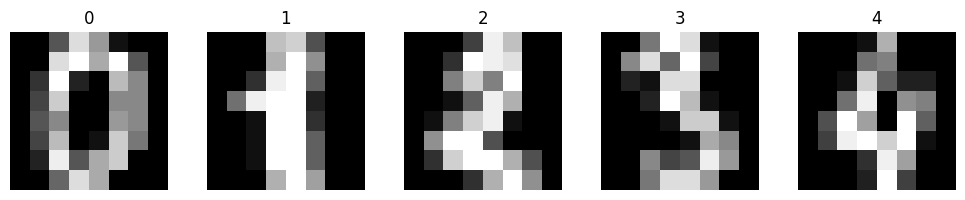

In [111]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(str(digits.target[i]))
    ax.axis("off")
plt.tight_layout()
plt.show()

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dig, y_dig, test_size=0.2, random_state=42, stratify=y_dig
)

scaler_d = StandardScaler()
X_train_d = scaler_d.fit_transform(X_train_d).astype(np.float32)
X_test_d = scaler_d.transform(X_test_d).astype(np.float32)

X_train_d_t = torch.tensor(X_train_d)  # [N_train, 64]
y_train_d_t = torch.tensor(y_train_d)  # [N_train] int64 class ids
X_test_d_t = torch.tensor(X_test_d)    # [N_test, 64]
y_test_d_t = torch.tensor(y_test_d)    # [N_test]

In [112]:
# Single-layer model: 64 pixel features -> 10 class logits
torch.manual_seed(42)
model_dig = nn.Linear(in_features=64, out_features=10)

print(model_dig.weight.shape)
print(model_dig.bias.shape)

torch.Size([10, 64])
torch.Size([10])


In [113]:
# Single forward pass -> raw logits (no softmax applied yet)
with torch.no_grad():
    test_logits_d = model_dig(X_test_d_t[:5])

print("Logits shape:", test_logits_d.shape)
print("Logits for first test image:", test_logits_d[0])

Logits shape: torch.Size([5, 10])
Logits for first test image: tensor([-0.9442,  0.6143,  0.7758, -0.1463,  0.5599,  0.2752,  0.9329, -0.0313,
        -0.3896, -0.5789])


In [114]:
# CrossEntropyLoss expects raw logits directly (it applies softmax + log internally)
criterion_ce = nn.CrossEntropyLoss()
ce_result = criterion_ce(test_logits_d, y_test_d_t[:5])

print(f"CrossEntropyLoss(raw logits): {ce_result.item():.4f}")

CrossEntropyLoss(raw logits): 2.1846


In [115]:
# We know softmax turns logits into class probabilities.
# Since we already have test_logits_d, let's compute probabilities ourselves...
test_probs_d = torch.softmax(test_logits_d, dim=1)

print("Probabilities for first test image:", test_probs_d[0])
print("Do they sum to 1?", test_probs_d[0].sum().item())

Probabilities for first test image: tensor([0.0297, 0.1412, 0.1660, 0.0660, 0.1337, 0.1006, 0.1942, 0.0740, 0.0517,
        0.0428])
Do they sum to 1? 1.0000001192092896
